# Correlation of Stocks Test Notebook

Correlation **Matrix** and **Line Graph** for a stock with others in a similar industry.

Plan is to implement this into a class and function which will show stock values alongside stocks within the same sector and how they're correlated. Maybe make a simple stock chart with functionality, beside it all of the other stocks that are peers or in the same industry (may need to look for another API for this), and then have a correlation matrix and rolling correlation plot (like below)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

In [2]:
tech_tickers = ['NVDA', 'MSFT', 'AAPL', 'GOOG', 'AMZN', 'META', 'AVGO', 'TSM', 'TSLA', 'ORCL']
tech_data = yf.download(tickers=tech_tickers, period='max')['Close']

fin_tickers = ['SAN', 'JPM', 'V', 'MA', 'BAC', 'WFC', 'MS', 'HSBC', 'AXP', 'GS']
fin_data = yf.download(fin_tickers, start='2020-01-01', end='2025-01-01')['Close']

/var/folders/ww/fq7r7t_57x3fk1xnj_kgz03h0000gn/T/ipykernel_21307/4172118624.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tech_data = yf.download(tickers=tech_tickers, period='max')['Close']
[*********************100%***********************]  10 of 10 completed
/var/folders/ww/fq7r7t_57x3fk1xnj_kgz03h0000gn/T/ipykernel_21307/4172118624.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  fin_data = yf.download(fin_tickers, start='2020-01-01', end='2025-01-01')['Close']
[*********************100%***********************]  10 of 10 completed


In [3]:
tech_returns = tech_data.pct_change().dropna()
fin_returns = fin_data.pct_change().dropna()

/var/folders/ww/fq7r7t_57x3fk1xnj_kgz03h0000gn/T/ipykernel_21307/2008376719.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  tech_returns = tech_data.pct_change().dropna()


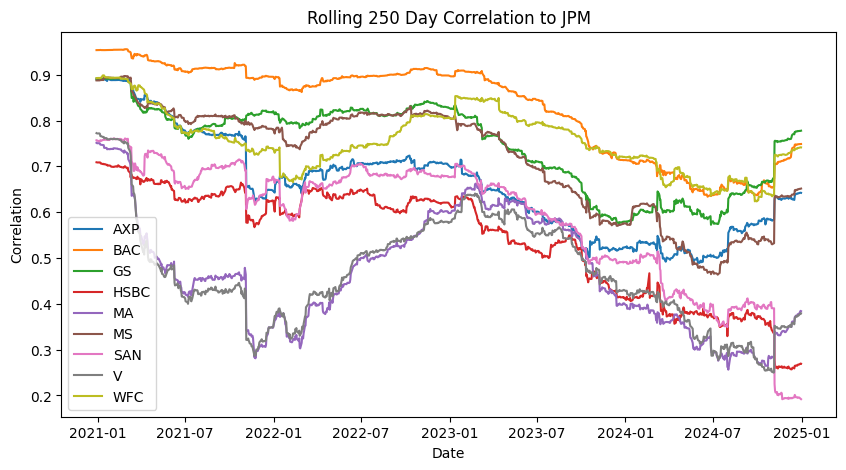

In [4]:
stock_ticker = 'JPM'
window = 250
fin_rolling_corr = pd.DataFrame()

for ticker in fin_returns.columns:
    if ticker != stock_ticker:
        fin_rolling_corr[ticker] = fin_returns[stock_ticker].rolling(window=window).corr(fin_returns[ticker])

plt.figure(figsize = (10,5))
for ticker in fin_rolling_corr.columns:
    plt.plot(fin_rolling_corr.index, fin_rolling_corr[ticker], label = f'{ticker}')

plt.title(f'Rolling {window} Day Correlation to {stock_ticker}')
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.legend()
plt.show()

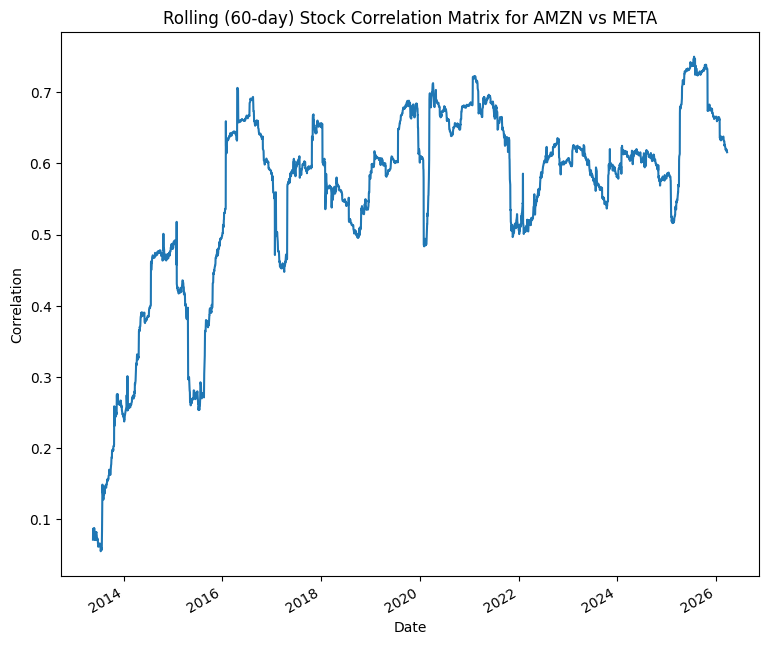

In [5]:
corr_stock1 = 'AMZN'
corr_stock2 = 'META'

rolling_corr = tech_returns[corr_stock1].rolling(window=250).corr(tech_returns[corr_stock2])

plt.figure(figsize = (9,8))
rolling_corr.plot()
plt.title(f'Rolling (60-day) Stock Correlation Matrix for {corr_stock1} vs {corr_stock2}')
plt.ylabel('Correlation')
#plt.axhline(0, color='k', linestyle='--')
plt.show()

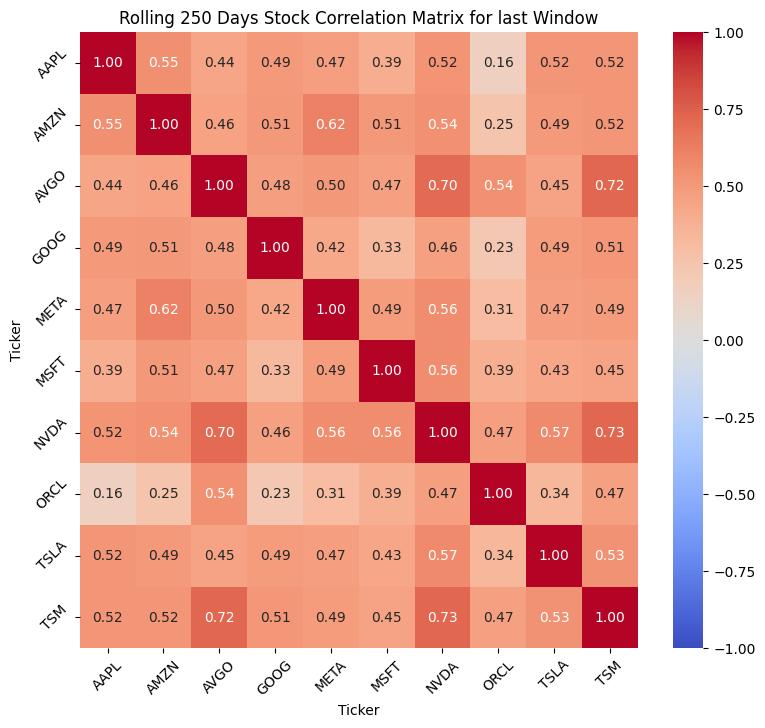

In [6]:
window = 250

rolling_corrs1 = tech_returns.rolling(window=250).corr()
last_corr = rolling_corrs1.loc[tech_returns.index[-1]]

plt.figure(figsize = (9,8))
sns.heatmap(last_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin = -1, vmax = 1)
plt.title(f'Rolling {window} Days Stock Correlation Matrix for last Window')
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

In [7]:
new_ticker = yf.Ticker('MCD')
print(new_ticker.info['sector'])

Consumer Cyclical
